In [3]:
import pandas as pd
df = pd.read_csv("heart.csv")
print(df.head())
print(df["target"].value_counts())

   age  sex  cp  trestbps  chol  fbs  thalach  exang  oldpeak  ca  target
0   49    0   3       177   150    0       95      0      2.3   0       0
1   56    1   0       124   172    1       86      1      0.5   0       1
2   66    0   3       100   239    0      105      0      1.7   0       0
3   64    0   0       168   222    0       95      1      2.8   0       1
4   60    1   2       153   358    0      147      0      3.2   0       1
1    11
0     5
Name: target, dtype: int64


In [4]:
X = df.drop("target", axis=1)
y = df["target"]
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
pred = dt.predict(X_test)
print(pred[:10])

[1 1 1 1]


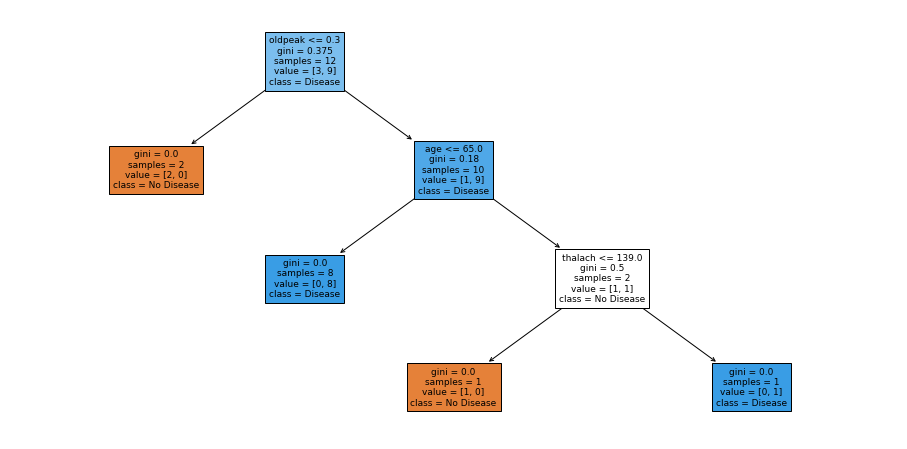

In [6]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
plt.figure (figsize = (16,8))
plot_tree (dt, feature_names = X.columns,
          class_names=["No Disease", "Disease"],
          filled=True, max_depth=3, fontsize=9)
plt.show()

In [7]:
for  depth in [2, 3, 4, 5, None]:
    dt_d = DecisionTreeClassifier(
    max_depth=depth, random_state=42
    )
    dt_d.fit(X_train, y_train)
    train_acc = dt_d.score(X_train, y_train)
    test_acc = dt_d.score(X_test, y_test)
    print(depth, train_acc, test_acc)

2 0.9166666666666666 0.5
3 1.0 0.5
4 1.0 0.5
5 1.0 0.5
None 1.0 0.5


In [9]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier (
    n_estimators=100, random_state=42
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

thalach     0.252615
oldpeak     0.241476
age         0.140648
trestbps    0.100706
chol        0.071112
cp          0.064972
ca          0.047406
exang       0.044012
sex         0.037053
fbs         0.000000
dtype: float64


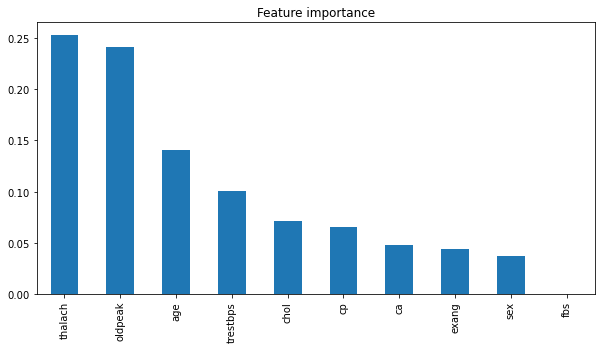

In [12]:
importances = rf.feature_importances_
feat_imp = pd.Series (
    importances, index=X.columns
).sort_values(ascending=False)
print(feat_imp)
feat_imp.plot(kind="bar", figsize=(10,5))
plt.title("Feature importance")
plt.show()

In [13]:
for n in [50, 100, 200]:
    for depth in [3, 5, None]:
        rf_t = RandomForestClassifier(
        n_estimators=n, max_depth=depth,
        random_state=42
        )
        rf_t.fit(X_train, y_train)
        acc = rf_t.score(X_test, y_test)
        print(n, depth, acc)

50 3 0.25
50 5 0.25
50 None 0.25
100 3 0.5
100 5 0.5
100 None 0.5
200 3 0.5
200 5 0.5
200 None 0.5


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "KNN (k=5)": KNeighborsClassifier(n_neighbors=5),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
}
results = []
for name, m in models.items():
    m.fit(X_train, y_train)
    p = m.predict(X_test)
    results.append([
        name,
        accuracy_score(y_test, p),
        precision_score(y_test, p),
        recall_score(y_test, p),
        f1_score(y_test, p),
    ])
comparision_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1 score"])
print(comparision_df)

                 Model  Accuracy  Precision  Recall  F1 score
0  Logistic Regression      0.25   0.333333     0.5  0.400000
1            KNN (k=5)      0.50   0.500000     1.0  0.666667
2        Decision Tree      0.50   0.500000     1.0  0.666667
3        Random Forest      0.50   0.500000     1.0  0.666667
